# Report Task 1 - Group 12 
Authors 
Natasha Donner /
Nishant/
Sol

In [4]:
import numpy as np
from matplotlib import pyplot as plt

In [5]:
from keras.datasets import mnist

## Background to preprocessing

As a first step, a simple example was used to compute the covariance matrix from a NumPy array. The goal was to understand how variance and relationships between features are represented before applying more advanced preprocessing methods.

The covariance matrix was calculated using np.cov with rowvar=False, meaning that each column is treated as a feature and each row as an observation. The parameter bias=True was used so the normalization divides by n instead ofn−1. 
This exercise helps build intuition for later preprocessing steps such as normalization , standardization and whitening.

In [6]:
A = np.array([[1, 3, 5], [5, 4, 1], [3, 8, 6]])


In [7]:
np.cov(A, rowvar=False, bias=True)

array([[ 2.66666667,  0.66666667, -2.66666667],
       [ 0.66666667,  4.66666667,  2.33333333],
       [-2.66666667,  2.33333333,  4.66666667]])

In [8]:
def calculateCovariance(X):
    meanX = np.mean(X, axis = 0)
    lenX = X.shape[0]
    X = X - meanX
    covariance = X.T.dot(X)/lenX
    return covariance

In [9]:
calculateCovariance(A)

array([[ 2.66666667,  0.66666667, -2.66666667],
       [ 0.66666667,  4.66666667,  2.33333333],
       [-2.66666667,  2.33333333,  4.66666667]])

## Visualize data and convariance matrix

The next step was to learn how to visualize both the dataset and its covariance matrix. Visualization helps build intuition about how features are distributed and how they relate to each other. 

In [10]:
import seaborn as sns
# Seaborn is used only for visualization, not math:

def plotDataAndCov(data):
    ACov = np.cov(data, rowvar=False, bias=True) 
    # rowvar=False => columns = features, rows=observations 
    # bias=True => divides by n instead of n-1
    print('Covariance matrix:\n', ACov)
    
    # Create a figure with two subplots (one for covariance, one for data)
    fig, ax = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(10, 10)

    ax0 = plt.subplot(2, 2, 1)

    # Choosing the colors
    cmap = sns.color_palette("GnBu", 10)
    sns.heatmap(ACov, cmap=cmap, vmin=0)

    ax1 = plt.subplot(2, 2, 2)

    # data can include the colors
    if data.shape[1]==3:
        c=data[:,2]
    else:
        c="#0A98BE"
    
    # Scatter plot of the first two features
    ax1.scatter(data[:,0], data[:,1], c=c, s=40)

    # Remove the top and right axes from the data plot
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)


Random numpy array is created

In [11]:
np.random.seed(1234)
a1 = np.random.normal(2, 1, 300)
a2 = np.random.normal(1, 1, 300)
A = np.array([a1, a2]).T
A.shape


(300, 2)

In [12]:
A[:10,:]

array([[ 2.47143516,  1.52704645],
       [ 0.80902431,  1.7111124 ],
       [ 3.43270697,  0.78245452],
       [ 1.6873481 ,  3.63779121],
       [ 1.27941127, -0.74213763],
       [ 2.88716294,  0.90556519],
       [ 2.85958841,  2.43118375],
       [ 1.3634765 ,  1.59275845],
       [ 2.01569637,  1.1702969 ],
       [-0.24268495, -0.75170595]])

mnist.load_data returns two tuples of data 
(
  (training_images, training_labels),
  (test_images, test_labels)
)
The line below unpacks the tuples


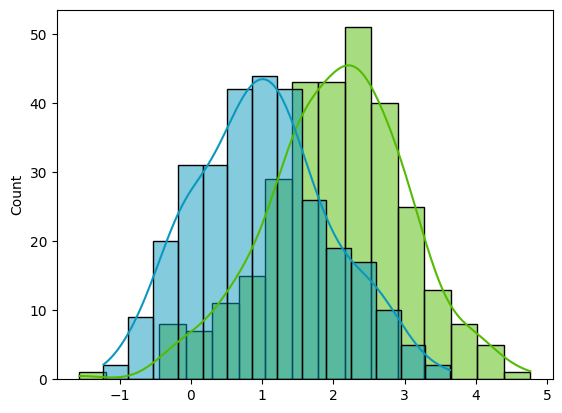

In [13]:
sns.histplot(A[:, 0], color="#53BB04", kde=True)
sns.histplot(A[:, 1], color="#0A98BE", kde=True)
plt.show()
plt.close()

Covariance matrix:
 [[ 0.95171641 -0.0447816 ]
 [-0.0447816   0.87959853]]


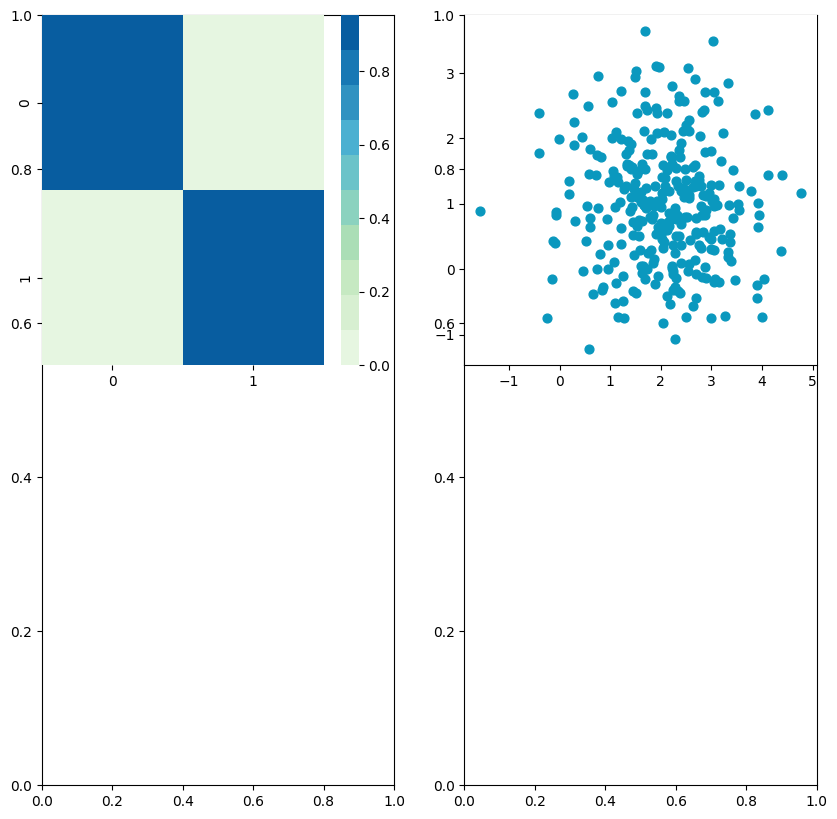

In [14]:
plotDataAndCov(A)
plt.show()
plt.close()

## Visualize data of two dependent features 
b2 column is specified from b1

Covariance matrix:
 [[0.95171641 0.92932561]
 [0.92932561 1.12683445]]


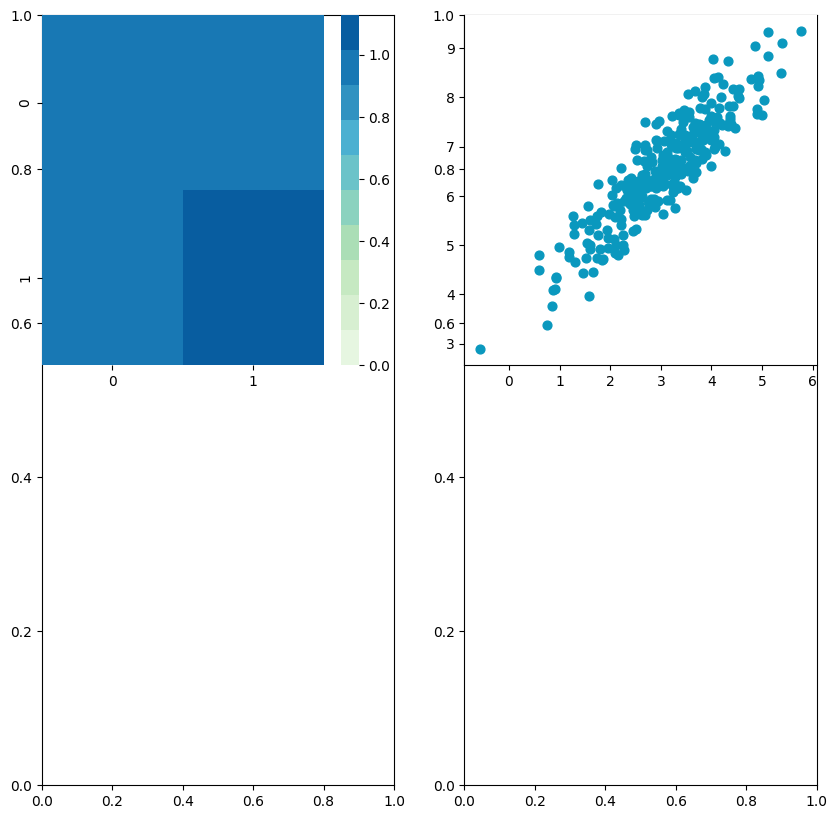

In [15]:
np.random.seed(1234)
b1 =  np.random.normal(3, 1, 300)
b2 = b1 + np.random.normal(7, 1, 300)/2.
B = np.array([b1, b2]).T
plotDataAndCov(B)
plt.show()
plt.close()

## Preprocessing data guidlines

### Mean normalization

Mean normalization is removing the mean value from each observed value.

In [16]:
def center(X):
    newX = X - np.mean(X, axis = 0)
    return newX

Before:


Covariance matrix:
 [[0.95171641 0.92932561]
 [0.92932561 1.12683445]]


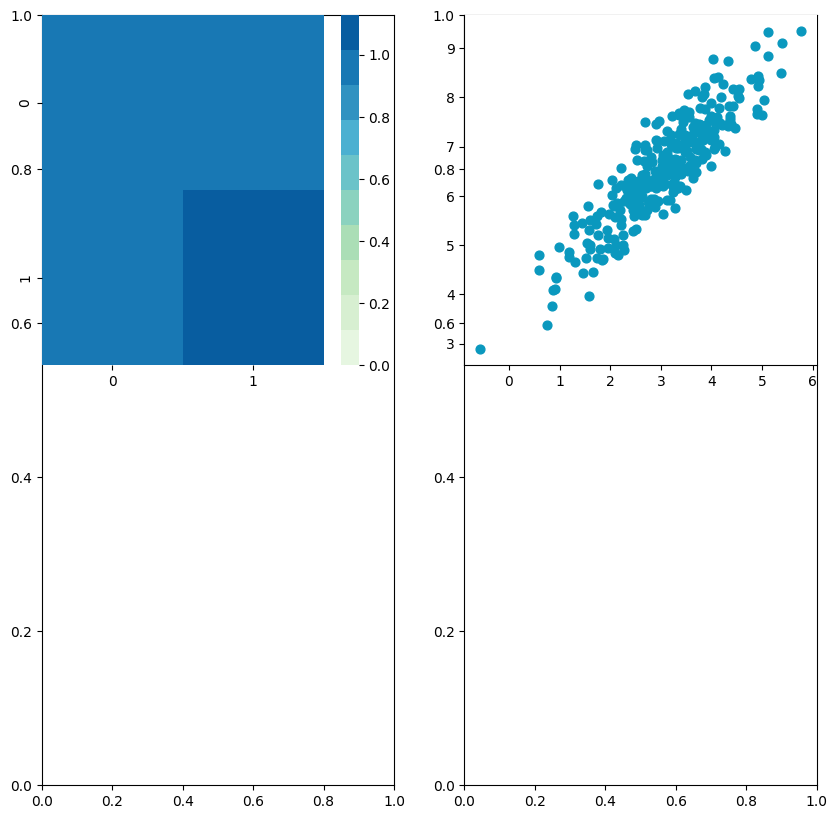

After:


Covariance matrix:
 [[0.95171641 0.92932561]
 [0.92932561 1.12683445]]


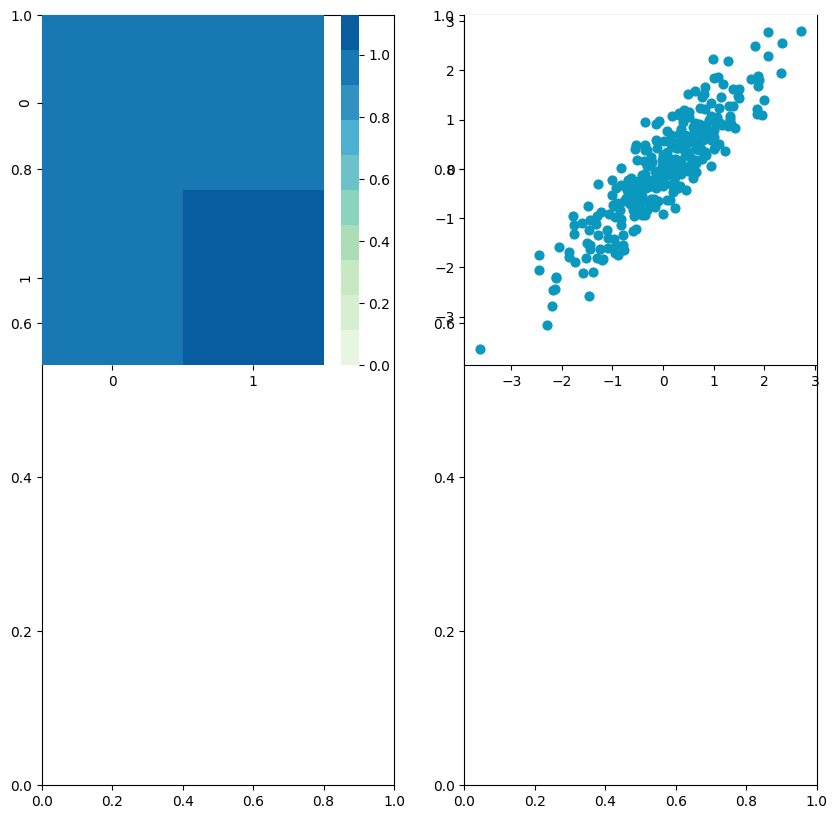

In [43]:
BCentered = center(B)

print('Before:\n\n')

plotDataAndCov(B)
plt.show()
plt.close()

print('After:\n\n')

plotDataAndCov(BCentered)
plt.show()
plt.close()

### Standardization

The standardization is used to get all the features in the same scale. 
How to do this is used the normalized value and divide it by the standard deviation. 

We define the function standardize() below which does this calculation for us. 

In [38]:
def standardize(X):
    newX = center(X)/np.std(X, axis = 0)
    return newX

Then we create a new dataset with a different scale, we plot the convariance. 

Covariance matrix:
 [[0.95171641 0.83976242]
 [0.83976242 6.22529922]]


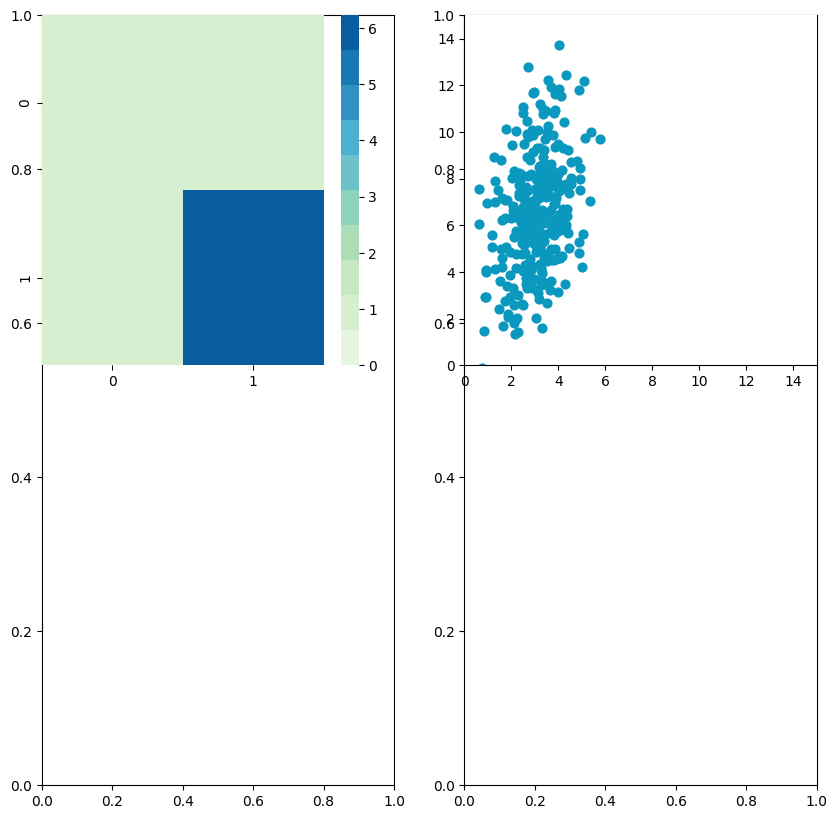

In [44]:
np.random.seed(1234)
c1 =  np.random.normal(3, 1, 300)
c2 = c1 + np.random.normal(7, 5, 300)/2.
C = np.array([c1, c2]).T

plotDataAndCov(C)
plt.xlim(0, 15)
plt.ylim(0, 15)
plt.show()
plt.close()

Now we take the same dataset (C) and standardize it before we plot it again.

Covariance matrix:
 [[1.         0.34500274]
 [0.34500274 1.        ]]


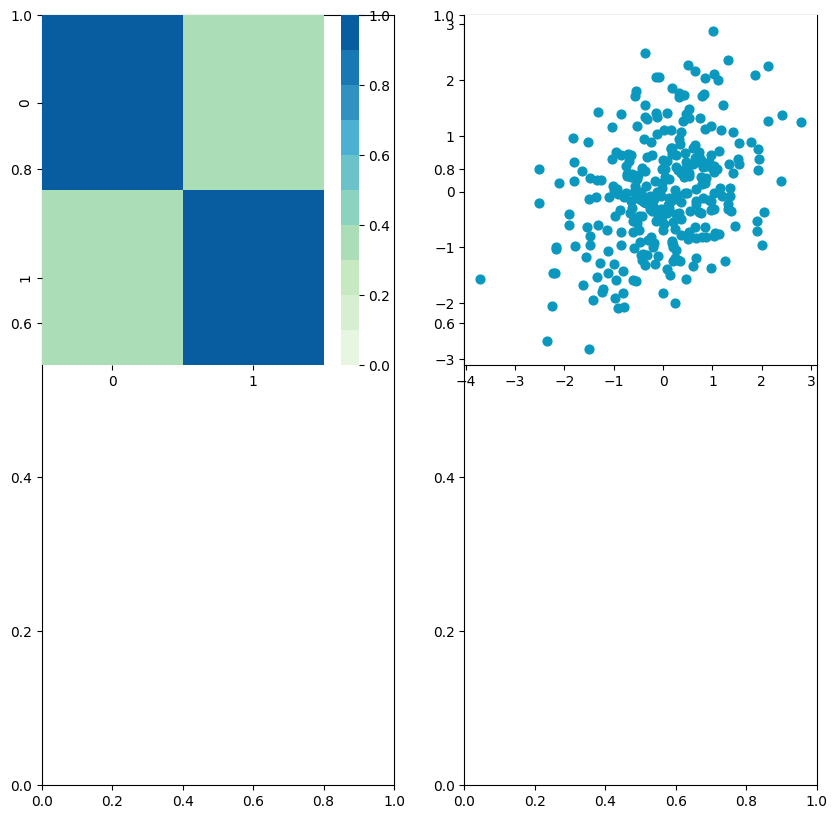

In [45]:
CStandardized = standardize(C)

plotDataAndCov(CStandardized)
plt.show()
plt.close()

As seen in the result the scale are now the same and the dataset is zero centered. 

## Whitening

Involves the following steps:

1. Zero-center data
2. Decorralate data
3. Rescale data

### 1. Zero center data

Covariance matrix:
 [[0.95171641 0.83976242]
 [0.83976242 6.22529922]]


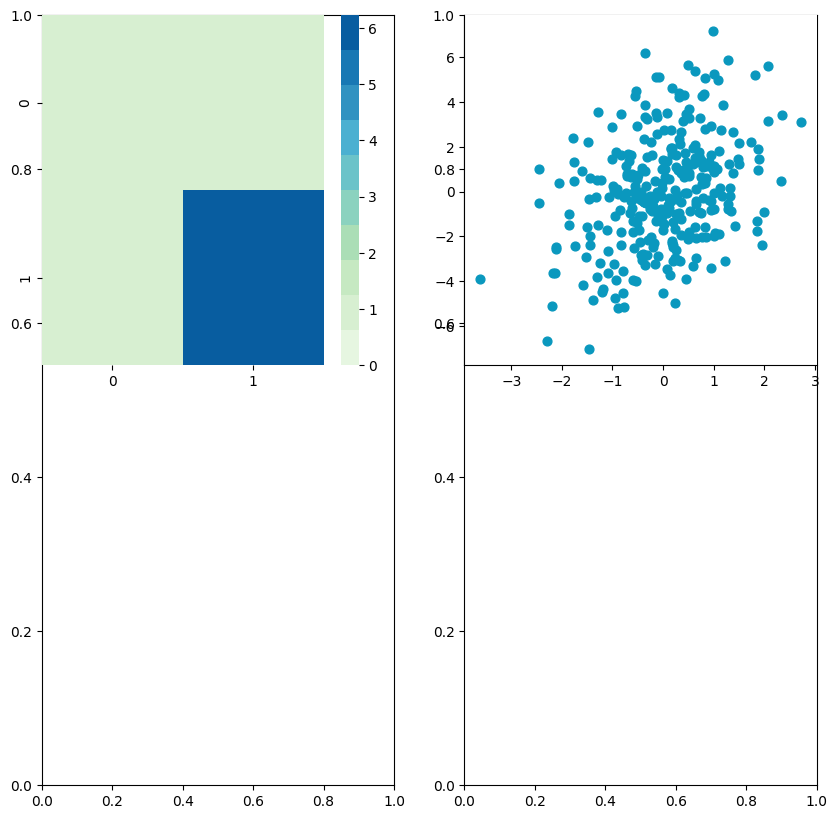

In [46]:
CCentered = center(C)

plotDataAndCov(CCentered)
plt.show()
plt.close()

### 2. Decorrelate

Decorerelate the data by turning it (projecting it on the eigen vector basis)

In [47]:
def decorrelate(X):
    XCentered = center(X)
    cov = XCentered.T.dot(XCentered)/float(XCentered.shape[0])
    # Calculate the eigenvalues and eigenvectors of the covariance matrix
    eigVals, eigVecs = np.linalg.eig(cov)
    # Apply the eigenvectors to X
    decorrelated = X.dot(eigVecs)
    return decorrelated

Covariance matrix:
 [[0.95171641 0.83976242]
 [0.83976242 6.22529922]]


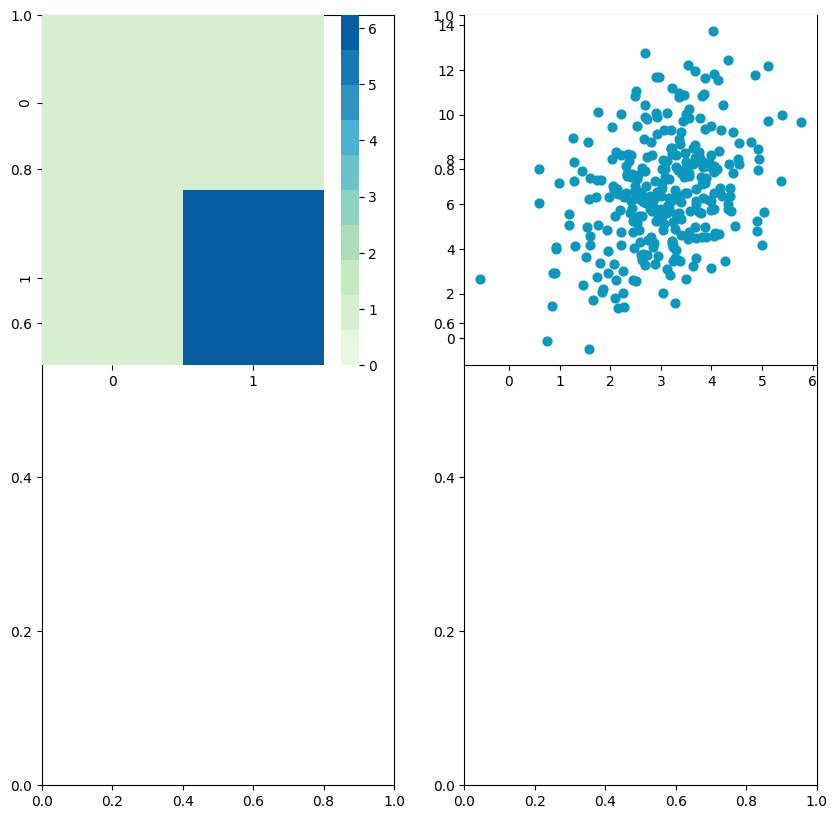

Covariance matrix:
 [[ 8.21222171e-01 -2.60532336e-16]
 [-2.60532336e-16  6.35579346e+00]]


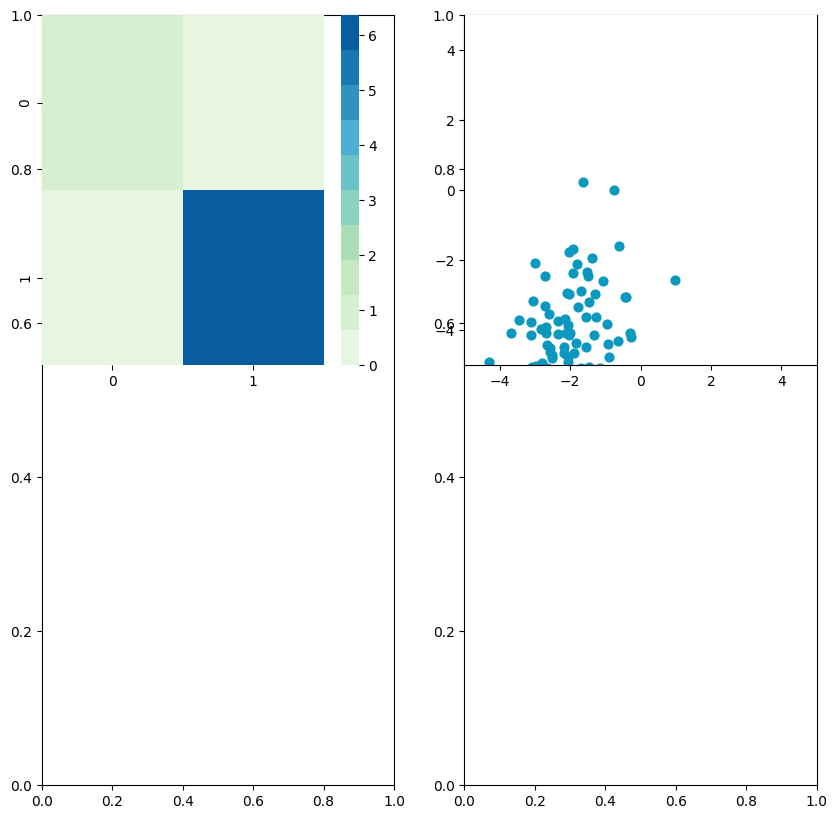

In [48]:
plotDataAndCov(C)
plt.show()
plt.close()

CDecorrelated = decorrelate(C)
plotDataAndCov(CDecorrelated)
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.show()
plt.close()

### 3. Rescale data 
Rescale data to obtain covariance matrix corresponding to the identity matrix.


In [49]:
def whiten(X):
    XCentered = center(X)
    cov = XCentered.T.dot(XCentered)/float(XCentered.shape[0])
    # Calculate the eigenvalues and eigenvectors of the covariance matrix
    eigVals, eigVecs = np.linalg.eig(cov)
    # Apply the eigenvectors to X
    decorrelated = X.dot(eigVecs)
    # Rescale the decorrelated data
    whitened = decorrelated / np.sqrt(eigVals + 1e-5) ## small value added to avoid division with zero
    return whitened

Covariance matrix:
 [[ 9.99987823e-01 -1.09542005e-16]
 [-1.09542005e-16  9.99998427e-01]]


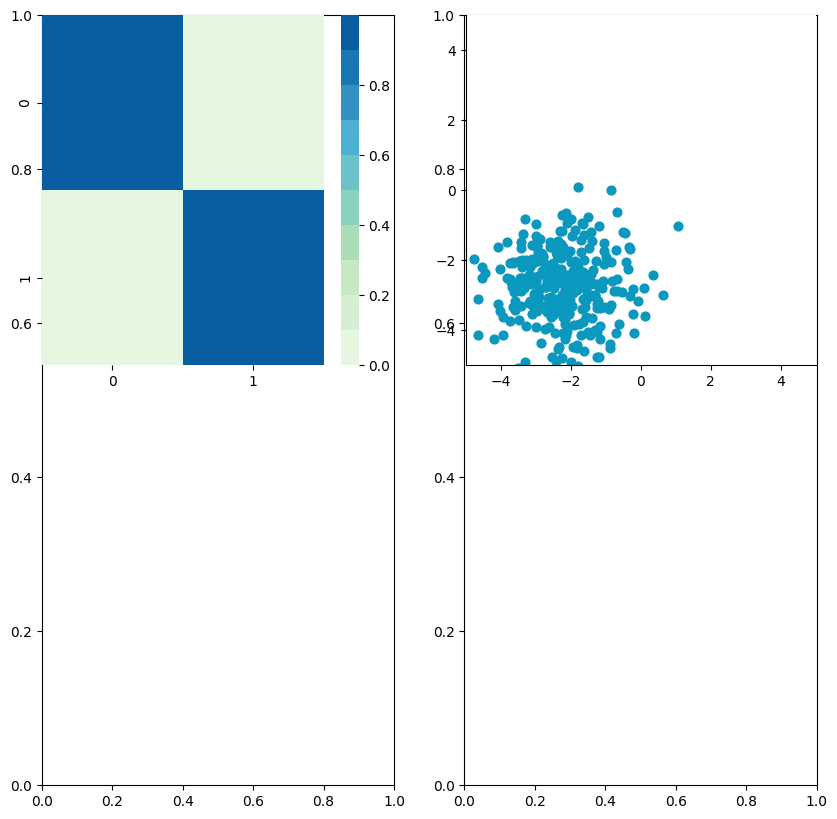

In [50]:
CWhitened = whiten(C)

plotDataAndCov(CWhitened)
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()
plt.close()

## Task 1 - preprocessing our mnist dataset

The first step is to load the dataset into tuples with training data and traing labels, and then also test data and test labels. 

In [116]:
(Xtr, Ltr), (X_test, L_test)=mnist.load_data()

Xtr.shape returns the dimensions (shape) of the array Xtr.
Xtr = training images
Each image is 28 × 28 pixels
There are 60,000 training images

In [117]:
Xtr.shape

(60000, 28, 28)

We can see that the type of the data is a unsigned integer. We cast this to float instead.

In [118]:
Xtr.dtype

dtype('uint8')

In [130]:
Xtr = Xtr.astype(np.float32)
X_test = X_test.astype(np.float32)


## Define functions to be used to pre-process the data

We gather all the functions that we tried out earlier in “Preprocessing for deep learning” tutorial. 

In [ ]:
# Preprocessing functions
def center(X):
    newX = X - np.mean(X, axis = 0)
    return newX

def standardize(X):
    '''Several pixels in the MNIST dataset 
    have zero variance because they are always zero across all samples.
     Therfore we change the code for the function to include an epsilon.'''

    epsilon = 1e-8
    newX = X / (np.std(X, axis=0) + epsilon) #std is 
    return newX





### Normalize dataset
Next step is to normalize the data, we use the function from the guidlines that we defined earlier

In [ ]:
Xtr_centered = center(Xtr)
X_test_centered = center(X_test)

### Standardize dataset
Next step is to standardize the dataset, we use the function from the guidlines that we defined earlier. 

In [152]:
Xtr_standardized = standardize(Xtr_centered)
X_test_standardized = standardize(X_test_centered)

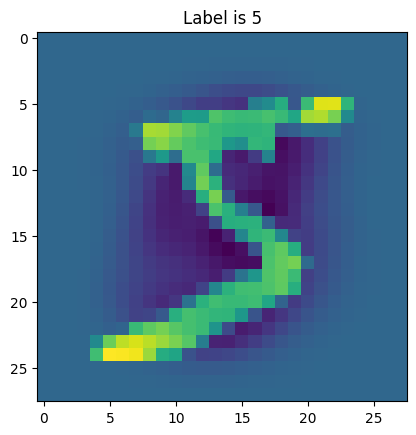

In [137]:
Image=Xtr_centered[0,:,:]
Label=Ltr[0]


plt.title('Label is {Label}'.format(Label=Label))
plt.imshow(Image)

plt.show()
plt.close()


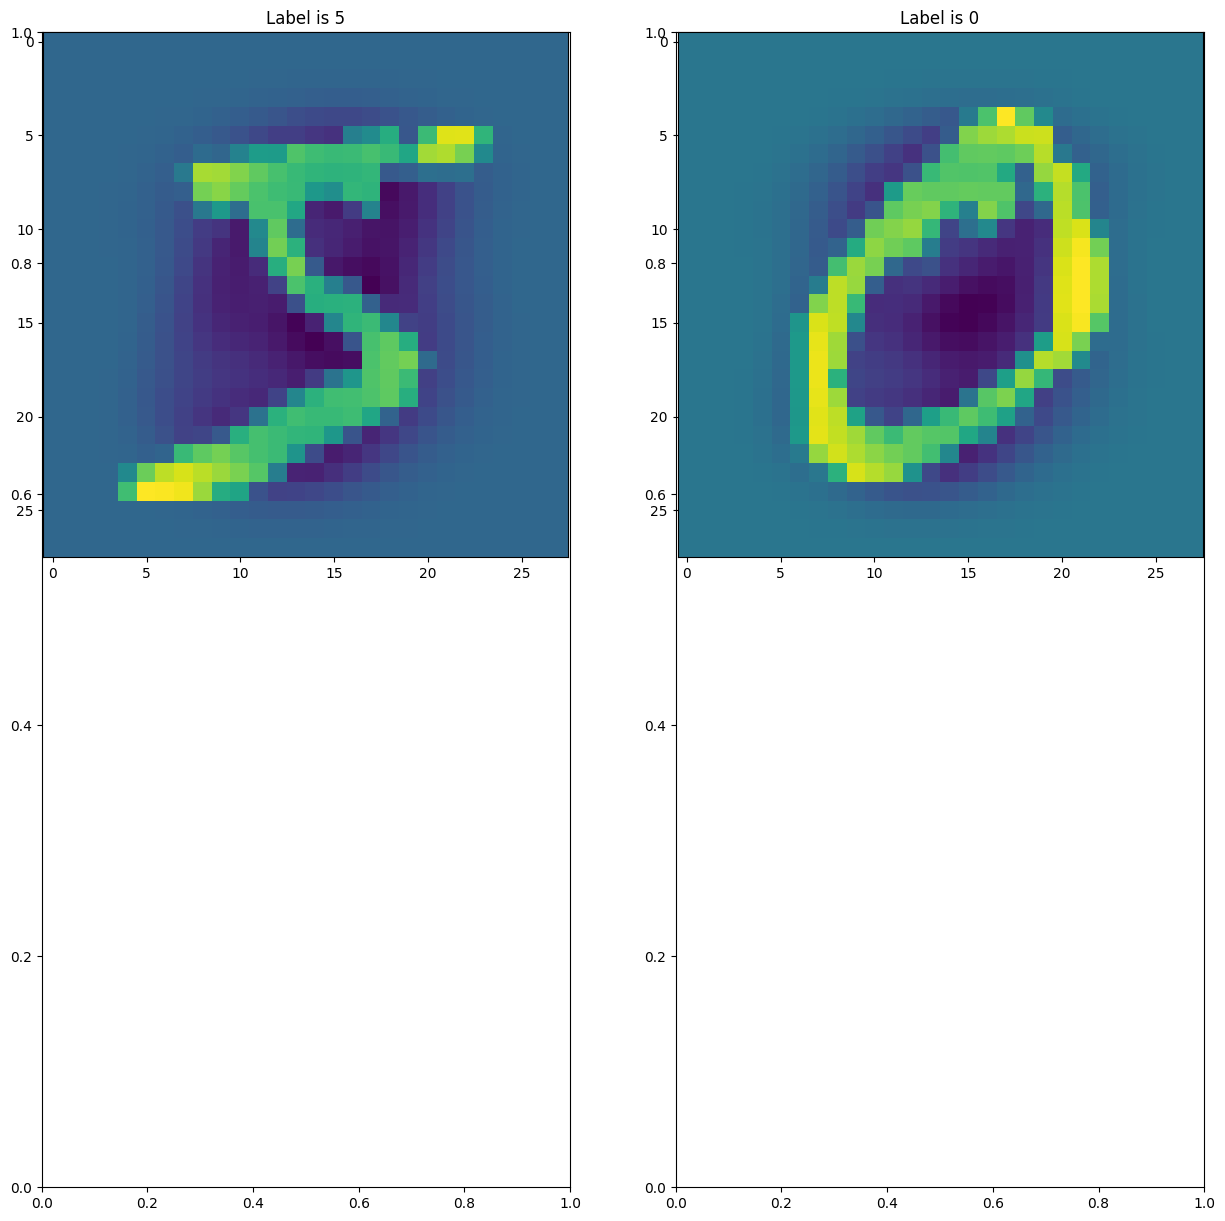

In [138]:
fig, ax=plt.subplots(nrows=1, ncols=2, figsize=(15,15))
ax0=plt.subplot(2,2,1)
ax1=plt.subplot(2,2,2)

Image=Xtr[0,:,:]
Label=Ltr[0]
Image1=Xtr[1,:,:]
Label1=Ltr[1]


ax0.set_title('Label is {Label}'.format(Label=Label))
ax0.imshow(Image)
ax1.set_title('Label is {Label}'.format(Label=Label1))
ax1.imshow(Image1)


plt.show()
plt.close()


In [139]:
28*28

784

In [140]:
#Traing phase
num_sample=500
Tr_set=Xtr[:num_sample,:,:]
Ltr_set=Ltr[:num_sample]

Tr_set=Tr_set.reshape(num_sample,Tr_set.shape[1]*Tr_set.shape[2])

#Tr_set=Tr_set.reshape(num_sample,Tr_set.shape[1]*Tr_set.shape[2]).astype()
Tr_set.shape

(500, 784)

In [141]:
def predict(X):
    num_test=X.shape[0]
    Lpred=np.zeros(num_test, dtype=Ltr_set.dtype)
    
    for i in range(num_test):
        distances=np.sum(np.abs(Tr_set-X[i,:]),axis=1)
        
        min_index= np.argmin(distances)
        Lpred[i]=Ltr_set[min_index]
    return Lpred

In [142]:
Test_images=X_test.reshape(X_test.shape[0],X_test.shape[1]* X_test.shape[2])
Labels_predicted=predict(Test_images)

print("Accuracy:", np.mean(Labels_predicted==L_test))



Accuracy: 0.811
